### Local geometry ###

In this lecture we will explore how kernels and local distances can be used to generalize Multi Dimensional Scaling to ISOMAP, and we will also look at flexible methods like tSNE and umap.

The key point will be to look at localized distances. We will also use this for flexible clustering through a graph representation of local distances: spectral clustering.

Let's revisit the iris data for illustration

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import KernelPCA
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans
from scipy.linalg import svd
from matplotlib.lines import Line2D

cbPalette = [
    "#999999", "#E69F00", "#56B4E9", "#009E73",
    "#F0E442", "#0072B2", "#D55E00", "#CC79A7"
]  # colour-blind friendly palette
bgCol = "#FAFAFA"
plt.rcParams["figure.facecolor"] = bgCol
plt.rcParams["axes.facecolor"] = bgCol
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def fig(width, height):
    plt.rcParams["figure.figsize"] = (width, height)


def scatter_panel(ax, df, x, y, group, title, xlabel=None, ylabel=None, palette=None):
    cats = pd.Categorical(df[group])
    if palette is None:
        palette = cbPalette[1:1 + len(cats.categories)]
    for i, cat in enumerate(cats.categories):
        mask = df[group] == cat
        ax.scatter(df.loc[mask, x], df.loc[mask, y], s=25, color=palette[i], label=str(cat))
    ax.set_title(title)
    ax.set_xlabel(xlabel if xlabel is not None else x)
    ax.set_ylabel(ylabel if ylabel is not None else y)


def hist_panel(ax, values, title, bins=25):
    ax.hist(np.ravel(values), bins=bins)
    ax.set_title(title)
    ax.set_xlabel("dist")


def heatmap_with_sidecolors(mat, row_colors, title, figsize=(8, 8)):
    fig, axes = plt.subplots(
        2, 2, figsize=figsize,
        gridspec_kw={"width_ratios": [0.15, 1], "height_ratios": [0.15, 1], "wspace": 0.02, "hspace": 0.02}
    )
    axes[0, 0].axis("off")
    axes[0, 1].imshow(np.array([row_colors]), aspect="auto")
    axes[0, 1].axis("off")
    axes[1, 0].imshow(np.array([row_colors]).T, aspect="auto")
    axes[1, 0].axis("off")
    im = axes[1, 1].imshow(mat, aspect="auto", interpolation="nearest")
    axes[1, 1].set_title(title)
    axes[1, 1].set_xticks([])
    axes[1, 1].set_yticks([])
    return fig, axes, im


def species_legend(ax, labels, colors):
    handles = [Line2D([0], [0], marker='o', linestyle='', color=c, label=l) for l, c in zip(labels, colors)]
    ax.legend(handles=handles, loc='lower right')


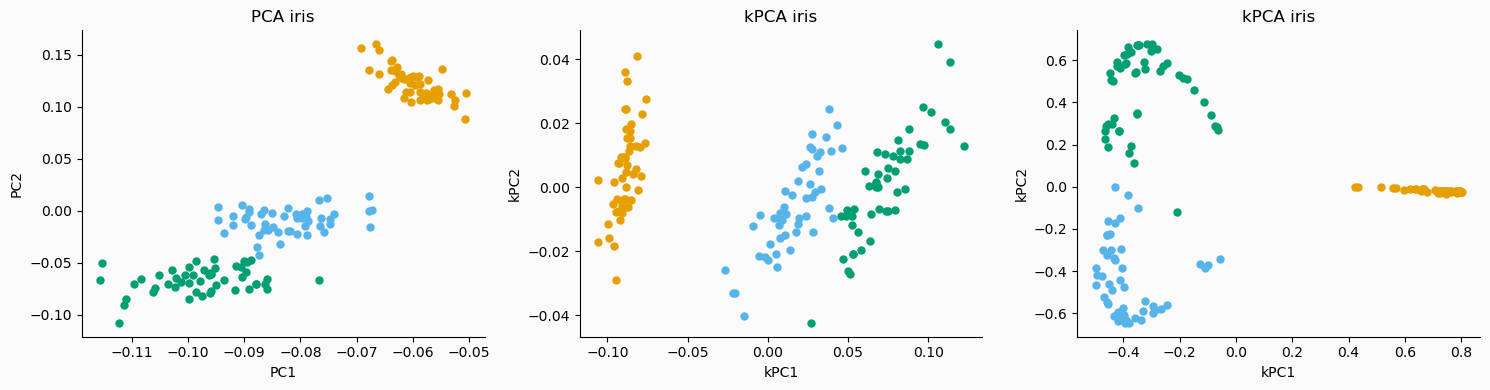

In [2]:

iris_bunch = load_iris(as_frame=True)
iris = iris_bunch.frame.copy()
iris["Species"] = iris_bunch.target_names[iris_bunch.target]
X_iris = iris.iloc[:, :-1].to_numpy()

U, s, Vt = svd(X_iris, full_matrices=False)  # PCA
pcs = pd.DataFrame(np.c_[U[:, :2], iris["Species"]], columns=["PC1", "PC2", "Species"])
pcs[["PC1", "PC2"]] = pcs[["PC1", "PC2"]].astype(float)

fig(15, 4)
fig_, axes = plt.subplots(1, 3, figsize=(15, 4))
scatter_panel(axes[0], pcs, "PC1", "PC2", "Species", title="PCA iris")

# Let's use kpca
ssk = KernelPCA(n_components=2, kernel="rbf", gamma=0.0005, eigen_solver="auto")

kpc1 = pd.DataFrame(ssk.fit_transform(X_iris), columns=["kPC1", "kPC2"])
kpc1["Species"] = iris["Species"].values
scatter_panel(axes[1], kpc1, "kPC1", "kPC2", "Species", title="kPCA iris")

# Let's kpca - different bandwidth
ssk = KernelPCA(n_components=2, kernel="rbf", gamma=0.5, eigen_solver="auto")
kpc2 = pd.DataFrame(ssk.fit_transform(X_iris), columns=["kPC1", "kPC2"])
kpc2["Species"] = iris["Species"].values
scatter_panel(axes[2], kpc2, "kPC1", "kPC2", "Species", title="kPCA iris")
plt.tight_layout()
plt.show()


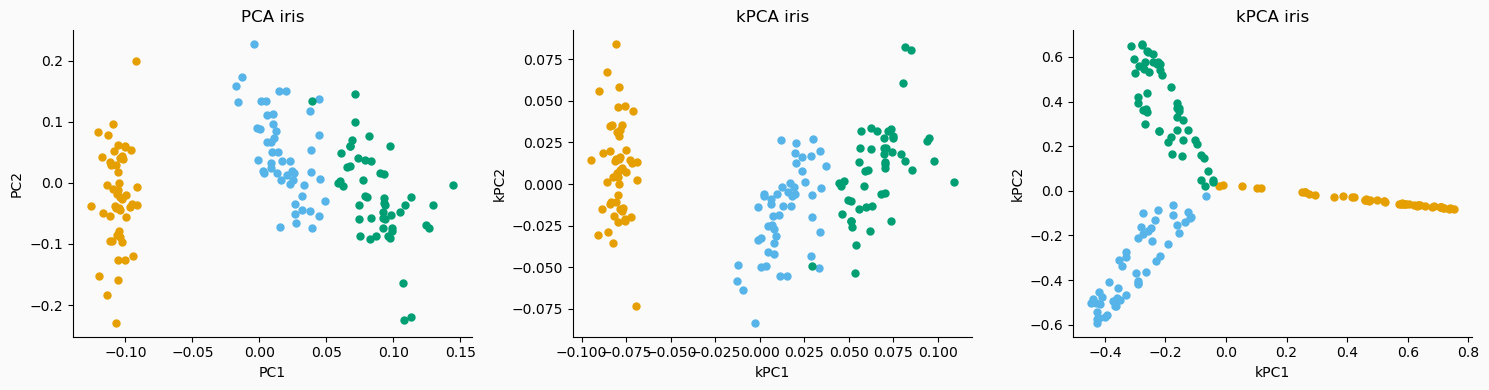

In [3]:
standardize = lambda x: (x - x.mean()) / x.std(ddof=1)

iris_s = iris.copy()
feature_cols = iris.columns[:-1]
iris_s[feature_cols] = iris[feature_cols].astype(float).apply(standardize, axis=0)
X_iris_s = iris_s[feature_cols].to_numpy()

U, s, Vt = svd(X_iris_s, full_matrices=False)
pcs = pd.DataFrame(np.c_[U[:, :2], iris_s["Species"]], columns=["PC1", "PC2", "Species"])
pcs[["PC1", "PC2"]] = pcs[["PC1", "PC2"]].astype(float)

fig(15, 4)
fig_, axes = plt.subplots(1, 3, figsize=(15, 4))
scatter_panel(axes[0], pcs, "PC1", "PC2", "Species", title="PCA iris")

ssk = KernelPCA(n_components=2, kernel="rbf", gamma=0.0005, eigen_solver="auto")
kpc2 = pd.DataFrame(ssk.fit_transform(X_iris_s), columns=["kPC1", "kPC2"])
kpc2["Species"] = iris_s["Species"].values
scatter_panel(axes[1], kpc2, "kPC1", "kPC2", "Species", title="kPCA iris")

ssk = KernelPCA(n_components=2, kernel="rbf", gamma=1.0, eigen_solver="auto")
kpc3 = pd.DataFrame(ssk.fit_transform(X_iris_s), columns=["kPC1", "kPC2"])
kpc3["Species"] = iris_s["Species"].values
scatter_panel(axes[2], kpc3, "kPC1", "kPC2", "Species", title="kPCA iris")
plt.tight_layout()
plt.show()


Let's work with the distances these kernels generate. Note, that for large $\sigma$, distances are aggressively turned into similarities, meaning as soon as there is a large distance this is pushed toward 0 similarity. For small $\sigma$ the rbf kernel behaves almost linearly which is why the kPCA and PCA look quite similar for those cases. 

Play with bandwidths here and explore.

In [4]:

deuc = pairwise_distances(X_iris)
deuc = 1 - deuc / deuc.max()  # similarity euclidean distance
drbf = rbf_kernel(X_iris, gamma=0.005)  # gaussian kernel (radial basis kernel function)
drbf2 = rbf_kernel(X_iris, gamma=1.0)   # gaussian kernel - more local


In [6]:
help(rbf_kernel)

Help on function rbf_kernel in module sklearn.metrics.pairwise:

rbf_kernel(X, Y=None, gamma=None)
    Compute the rbf (gaussian) kernel between X and Y.

    .. code-block:: text

        K(x, y) = exp(-gamma ||x-y||^2)

    for each pair of rows x in X and y in Y.

    Read more in the :ref:`User Guide <rbf_kernel>`.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples_X, n_features)
        A feature array.

    Y : {array-like, sparse matrix} of shape (n_samples_Y, n_features), default=None
        An optional second feature array. If `None`, uses `Y=X`.

    gamma : float, default=None
        If None, defaults to 1.0 / n_features.

    Returns
    -------
    kernel : ndarray of shape (n_samples_X, n_samples_Y)
        The RBF kernel.

    Examples
    --------
    >>> from sklearn.metrics.pairwise import rbf_kernel
    >>> X = [[0, 0, 0], [1, 1, 1]]
    >>> Y = [[1, 0, 0], [1, 1, 0]]
    >>> rbf_kernel(X, Y)
    array([[0.71, 0.51],
           [

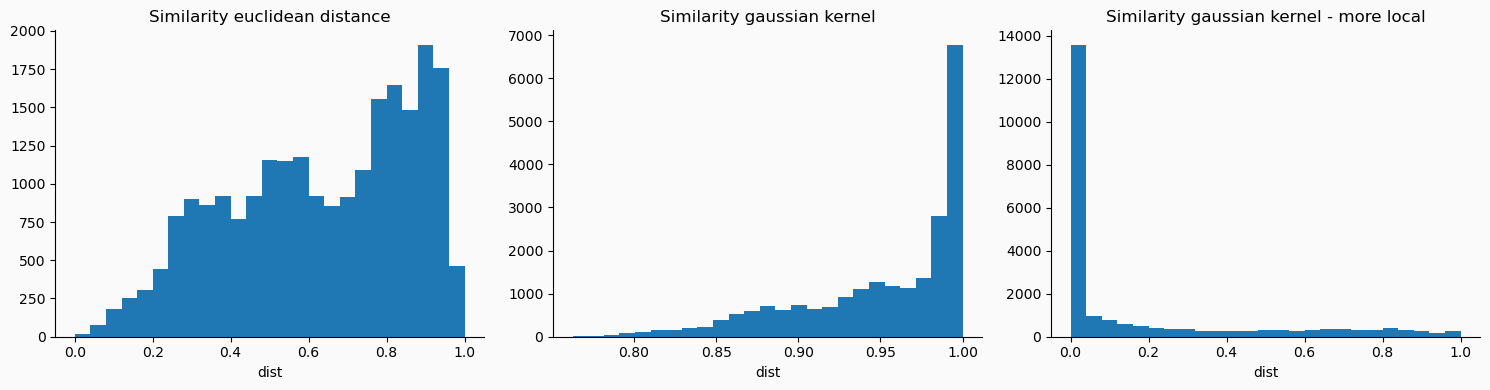

In [5]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
hist_panel(axes[0], deuc, "Similarity euclidean distance")
hist_panel(axes[1], drbf, "Similarity gaussian kernel")
hist_panel(axes[2], drbf2, "Similarity gaussian kernel - more local")
plt.tight_layout()
plt.show()


Notice how depending on $\sigma$ everyone is either "far" or "close" and different aspects of the data are emphasized. Let's have a look at the actual distance matrices that are generated by the kernels.

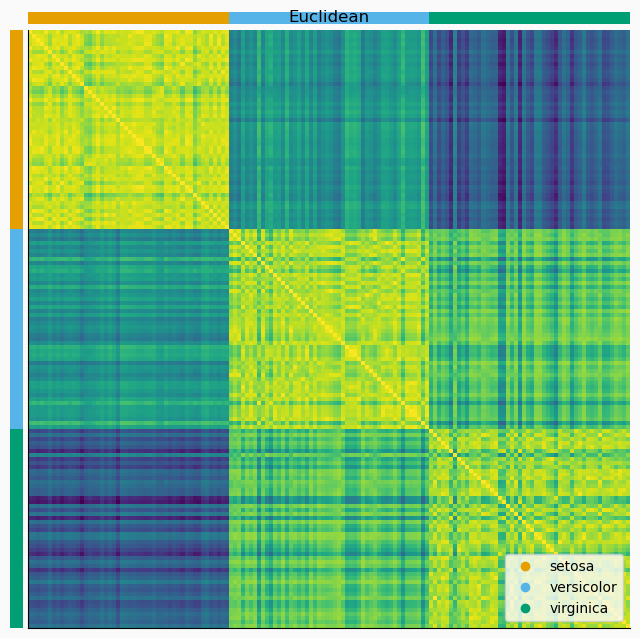

In [6]:
label_order = list(pd.Categorical(iris_s["Species"]).categories)
RC_labels = iris_s["Species"].values
RC_map = {
    label_order[0]: cbPalette[1],
    label_order[1]: cbPalette[2],
    label_order[2]: cbPalette[3],
}
row_colors = np.array([plt.matplotlib.colors.to_rgb(RC_map[s]) for s in RC_labels])


def heatmap_with_sidecolors(mat, row_colors, title, figsize=(8, 8), cmap="viridis"):
    fig, axes = plt.subplots(
        2, 2,
        figsize=figsize,
        gridspec_kw={
            "width_ratios": [0.4, 20],
            "height_ratios": [0.4, 20],
            "wspace": 0.02,
            "hspace": 0.02,
        },
    )

    axes[0, 0].axis("off")

    axes[0, 1].imshow(row_colors[None, :, :], aspect="auto")
    axes[0, 1].axis("off")

    axes[1, 0].imshow(row_colors[:, None, :], aspect="auto")
    axes[1, 0].axis("off")

    im = axes[1, 1].imshow(mat, aspect="auto", cmap=cmap)
    axes[1, 1].set_title(title)
    axes[1, 1].set_xticks([])
    axes[1, 1].set_yticks([])

    return fig, axes, im


fig_, axes, im = heatmap_with_sidecolors(deuc, row_colors, "Euclidean", figsize=(8, 8))
species_legend(axes[1, 1], label_order, [cbPalette[1], cbPalette[2], cbPalette[3]])
plt.show()


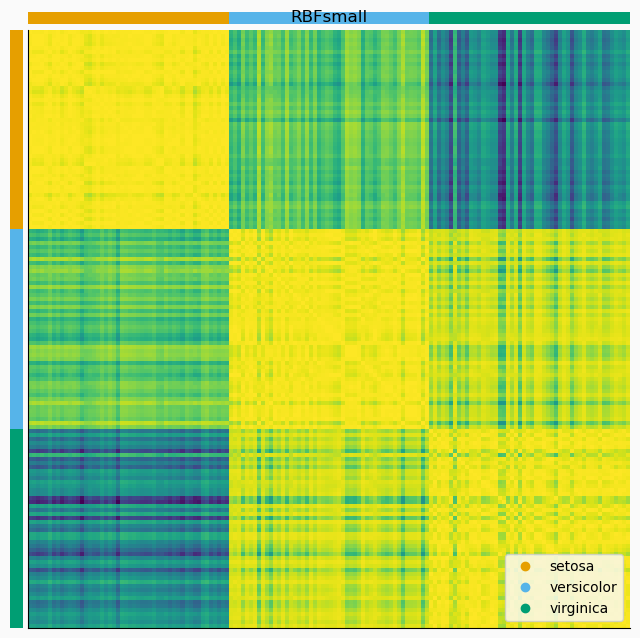

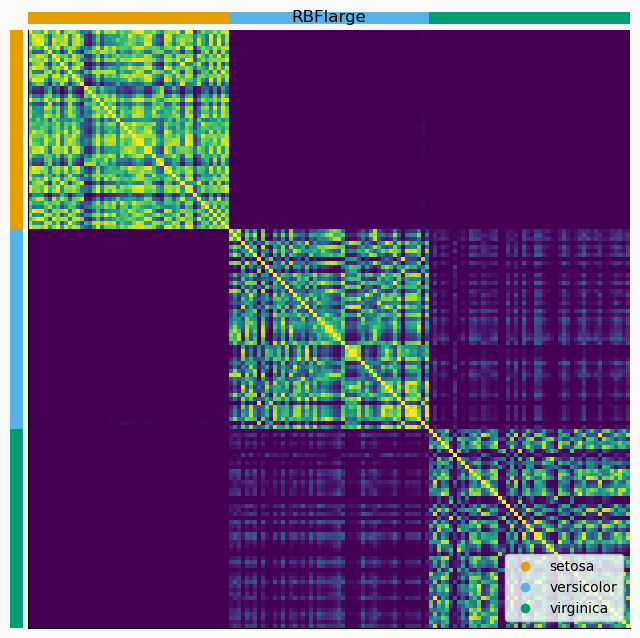

In [7]:
fig_, axes, im = heatmap_with_sidecolors(drbf, row_colors, "RBFsmall", figsize=(8, 8))
species_legend(axes[1, 1], label_order, [cbPalette[1], cbPalette[2], cbPalette[3]])
plt.show()

fig_, axes, im = heatmap_with_sidecolors(drbf2, row_colors, "RBFlarge", figsize=(8, 8))
species_legend(axes[1, 1], label_order, [cbPalette[1], cbPalette[2], cbPalette[3]])
plt.show()


Notice how a more "aggressive" distance perspective separates the classes from each other. 

Can this be used for clustering?

Let's threshold the similarities the 75th percentile (try different values at home) and see what happens.

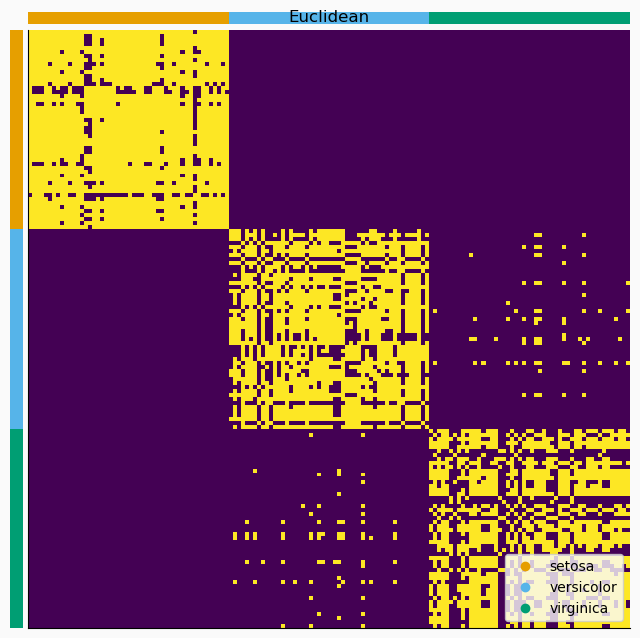

In [8]:
deuc_th = (deuc > np.quantile(deuc, 0.75)).astype(int)
drbf_th = (drbf > np.quantile(drbf, 0.75)).astype(int)
drbf2_th = (drbf2 > np.quantile(drbf2, 0.75)).astype(int)

fig_, axes, im = heatmap_with_sidecolors(deuc_th, row_colors, "Euclidean", figsize=(8, 8))
species_legend(axes[1, 1], label_order, [cbPalette[1], cbPalette[2], cbPalette[3]])
plt.show()

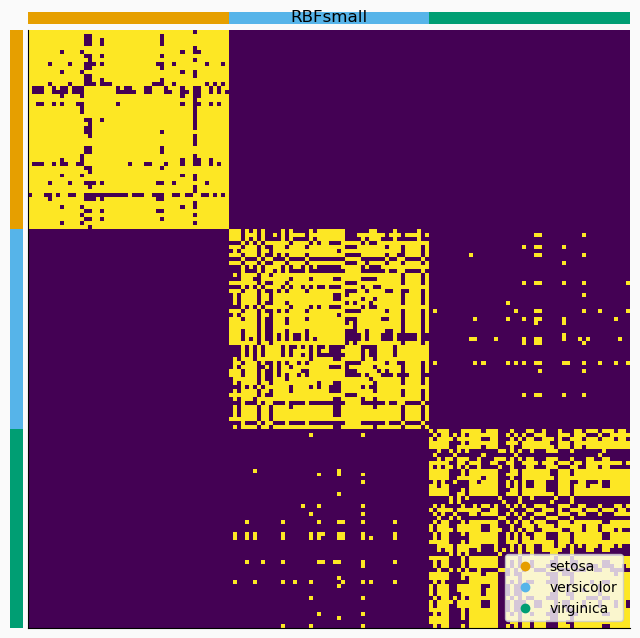

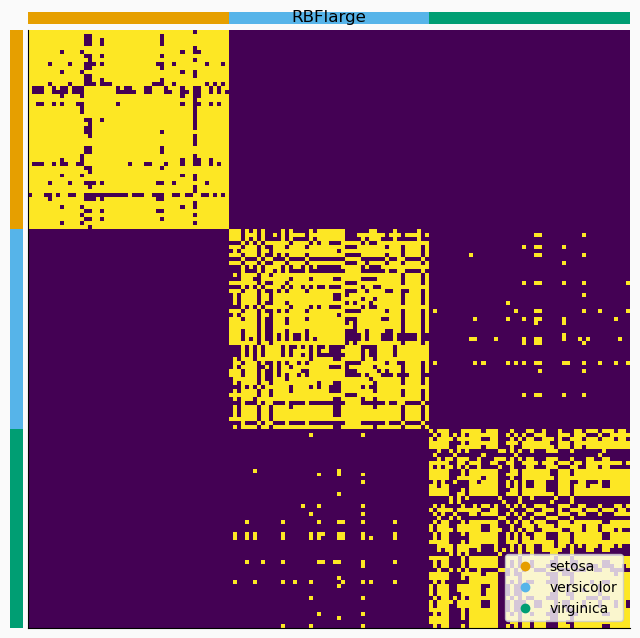

In [9]:
fig_, axes, im = heatmap_with_sidecolors(drbf_th, row_colors, "RBFsmall", figsize=(8, 8))
species_legend(axes[1, 1], label_order, [cbPalette[1], cbPalette[2], cbPalette[3]])
plt.show()

fig_, axes, im = heatmap_with_sidecolors(drbf2_th, row_colors, "RBFlarge", figsize=(8, 8))
species_legend(axes[1, 1], label_order, [cbPalette[1], cbPalette[2], cbPalette[3]])
plt.show()


For this easy example you get very similar results after thresholding the similarities. 

These thresholded similarities, the so-called adjacency matrices, can now be analyzed with PCA.

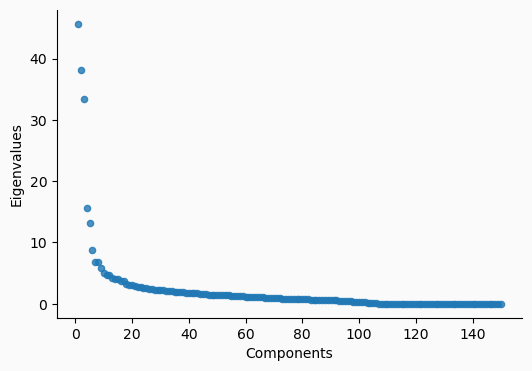

In [10]:

U, ssg2_d, Vt = svd(drbf2_th, full_matrices=False)
eigg2 = pd.DataFrame({"eigen": ssg2_d, "pc": np.arange(1, len(ssg2_d) + 1)})

plt.figure(figsize=(6, 4))
plt.scatter(eigg2["pc"], eigg2["eigen"], s=20, alpha=0.8)
plt.xlabel("Components")
plt.ylabel("Eigenvalues")
plt.show()


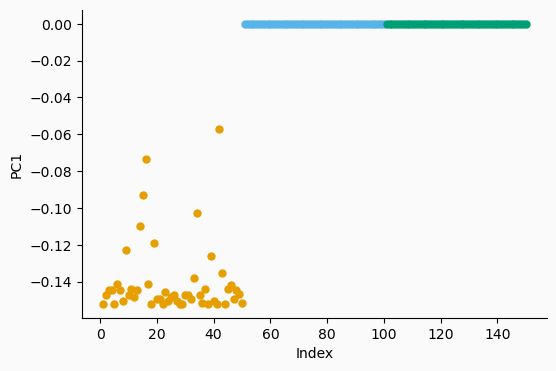

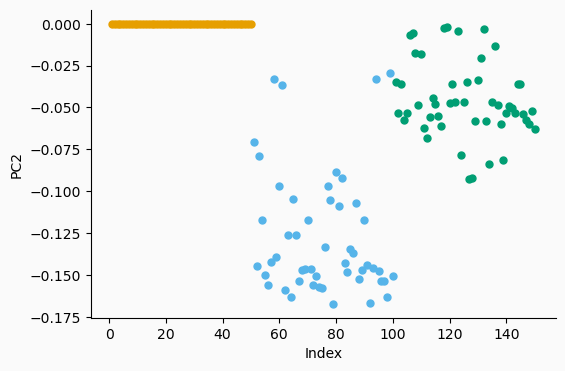

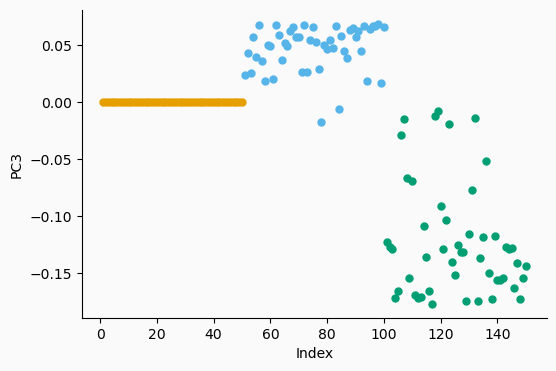

In [11]:

pcg2 = pd.DataFrame({
    "Index": np.arange(1, U.shape[0] + 1),
    "kPC1": U[:, 0],
    "kPC2": U[:, 1],
    "kPC3": U[:, 2],
    "Species": iris_s["Species"].values
})

for col, ylabel in zip(["kPC1", "kPC2", "kPC3"], ["PC1", "PC2", "PC3"]):
    plt.figure(figsize=(6, 4))
    ax = plt.gca()
    scatter_panel(ax, pcg2, "Index", col, "Species", title="", xlabel="Index", ylabel=ylabel)
    plt.show()


Notice how the leading PC components of the thresholded similarity matrix finds the groupings in the data. 

Of course for the iris data this was trivial. What about a more complicated data set?

In [12]:

np.random.seed(1)
n = 250
c1 = pd.DataFrame({"x": np.random.normal(size=n), "y": np.random.normal(size=n), "cluster": 1})
r = np.random.normal(5, 0.25, size=n)
theta = np.random.uniform(0, 2 * np.pi, size=n)
c2 = pd.DataFrame({"x": r * np.cos(theta), "y": r * np.sin(theta), "cluster": 2})

data_plot2 = pd.concat([c1, c2], ignore_index=True)
data_plot2["cluster"] = data_plot2["cluster"].astype(str)
data_plot2["colour"] = np.where(data_plot2["cluster"] == "1", cbPalette[1], cbPalette[2])


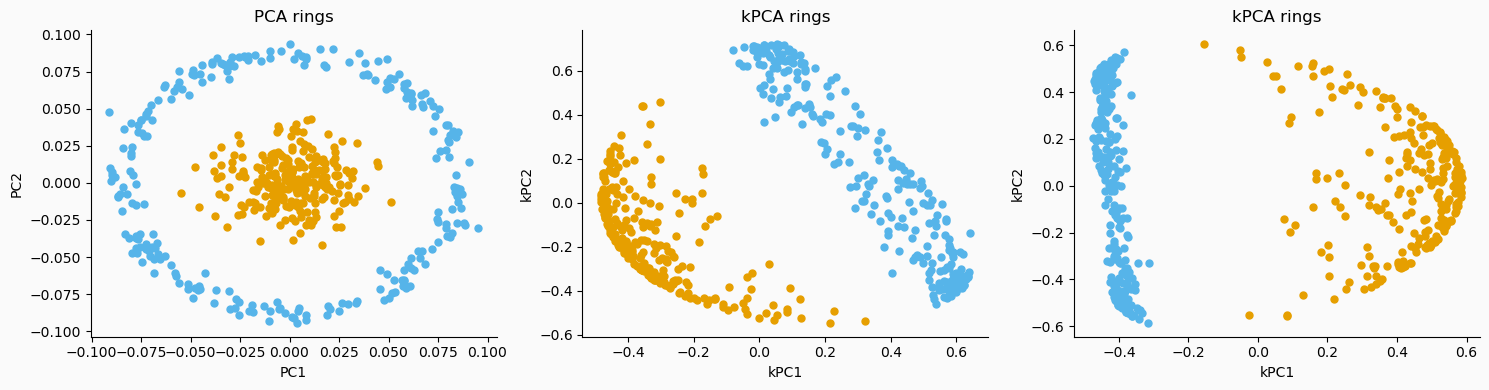

In [13]:

X_rings = data_plot2[["x", "y"]].to_numpy()
U, s, Vt = svd(X_rings, full_matrices=False)  # PCA
pc1 = pd.DataFrame(np.c_[U[:, :2], data_plot2["cluster"]], columns=["PC1", "PC2", "cluster"])
pc1[["PC1", "PC2"]] = pc1[["PC1", "PC2"]].astype(float)

fig_, axes = plt.subplots(1, 3, figsize=(15, 4))
scatter_panel(axes[0], pc1, "PC1", "PC2", "cluster", title="PCA rings")

# Let's kpca
ssk = KernelPCA(n_components=2, kernel="rbf", gamma=0.05, eigen_solver="auto")
pc2 = pd.DataFrame(ssk.fit_transform(X_rings), columns=["kPC1", "kPC2"])
pc2["cluster"] = data_plot2["cluster"].values
scatter_panel(axes[1], pc2, "kPC1", "kPC2", "cluster", title="kPCA rings")

# Let's kpca - different bandwidth
ssk = KernelPCA(n_components=2, kernel="rbf", gamma=0.1, eigen_solver="auto")
pc3 = pd.DataFrame(ssk.fit_transform(X_rings), columns=["kPC1", "kPC2"])
pc3["cluster"] = data_plot2["cluster"].values
scatter_panel(axes[2], pc3, "kPC1", "kPC2", "cluster", title="kPCA rings")
plt.tight_layout()
plt.show()


What's the optimal bandwidth? Here, we know we want to cluster so we can investigate for which bandwidth we get the tightest clusters. This is implemented in the spectral clustering method in 'kernlab'.

Let's now take a look at the graph induced by the linear and nonlinear kernels.

In [14]:

deuc = pairwise_distances(X_rings)
deuc = 1 - deuc / deuc.max()  # similarity euclidean distance
drbf = rbf_kernel(X_rings, gamma=0.05)  # gaussian kernel
drbf2 = rbf_kernel(X_rings, gamma=0.1)  # gaussian kernel - more local
# keeping the top 25% similarities
deuc_th = (deuc > np.quantile(deuc, 0.75)).astype(int)
drbf_th = (drbf > np.quantile(drbf, 0.75)).astype(int)
drbf2_th = (drbf2 > np.quantile(drbf2, 0.75)).astype(int)


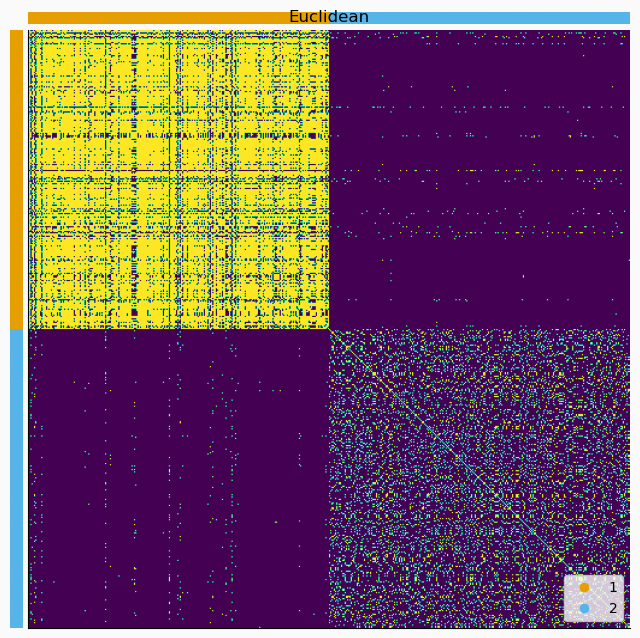

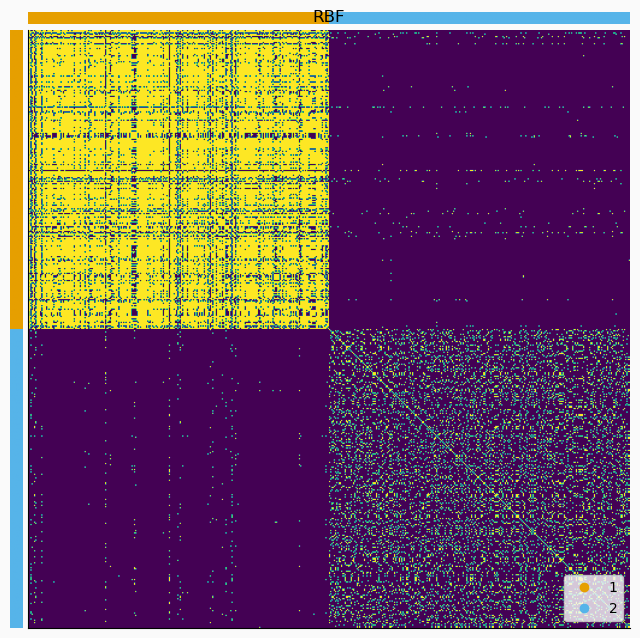

In [15]:

RC = np.array([
    plt.matplotlib.colors.to_rgb(cbPalette[1] if c == "1" else cbPalette[2])
    for c in data_plot2["cluster"]
])

fig_, axes, im = heatmap_with_sidecolors(deuc_th, RC, "Euclidean", figsize=(8, 8))
species_legend(axes[1, 1], sorted(data_plot2["cluster"].unique()), [cbPalette[1], cbPalette[2]])
plt.show()

fig_, axes, im = heatmap_with_sidecolors(drbf2_th, RC, "RBF", figsize=(8, 8))
species_legend(axes[1, 1], sorted(data_plot2["cluster"].unique()), [cbPalette[1], cbPalette[2]])
plt.show()


Once again, if we threshhold the distances we can see a cluster separation. This doesn't necessarily require that we use kPCA but it may make the treshhold selection easier.

That is, going from simularities to adjacencies is taking the role of working with a kernel - threshholding controls how local vs global you are.

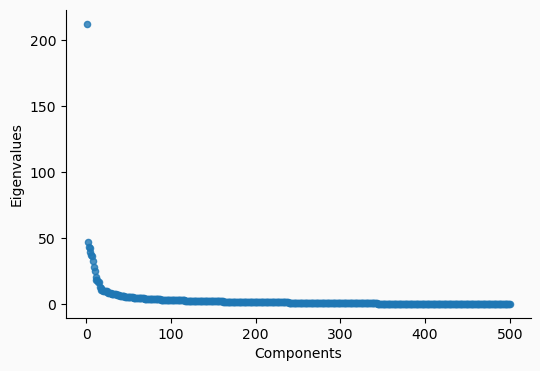

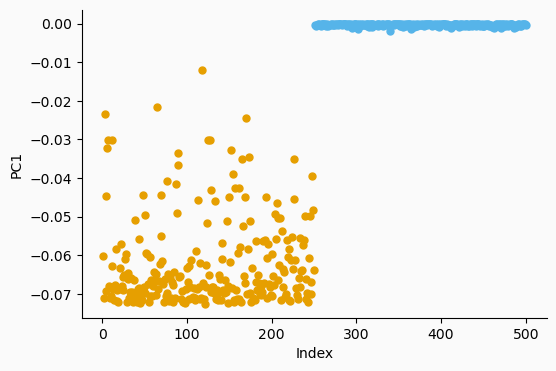

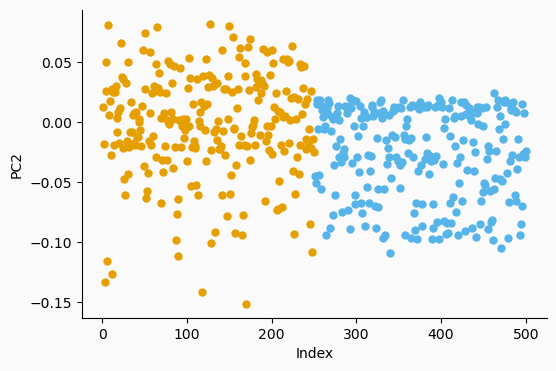

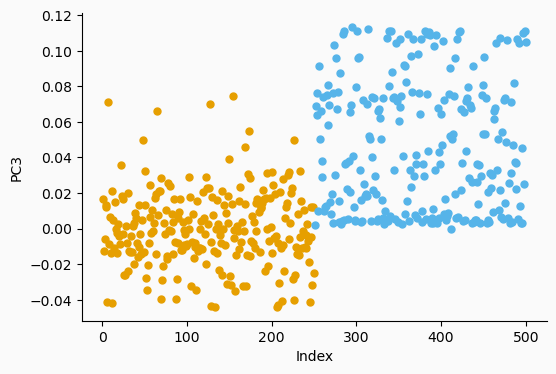

In [16]:

U, sseu_d, Vt = svd(deuc_th, full_matrices=False)

eigeu = pd.DataFrame({"eigen": sseu_d, "pc": np.arange(1, len(sseu_d) + 1)})
plt.figure(figsize=(6, 4))
plt.scatter(eigeu["pc"], eigeu["eigen"], s=20, alpha=0.8)
plt.xlabel("Components")
plt.ylabel("Eigenvalues")
plt.show()

pceu = pd.DataFrame({
    "Index": np.arange(1, U.shape[0] + 1),
    "PC1": U[:, 0],
    "PC2": U[:, 1],
    "PC3": U[:, 2],
    "cluster": data_plot2["cluster"].values
})

for col in ["PC1", "PC2", "PC3"]:
    plt.figure(figsize=(6, 4))
    ax = plt.gca()
    scatter_panel(ax, pceu, "Index", col, "cluster", title="", xlabel="Index", ylabel=col)
    plt.show()


Notice that the rings data are now separated already in the first principal component of the adjacency matrix.

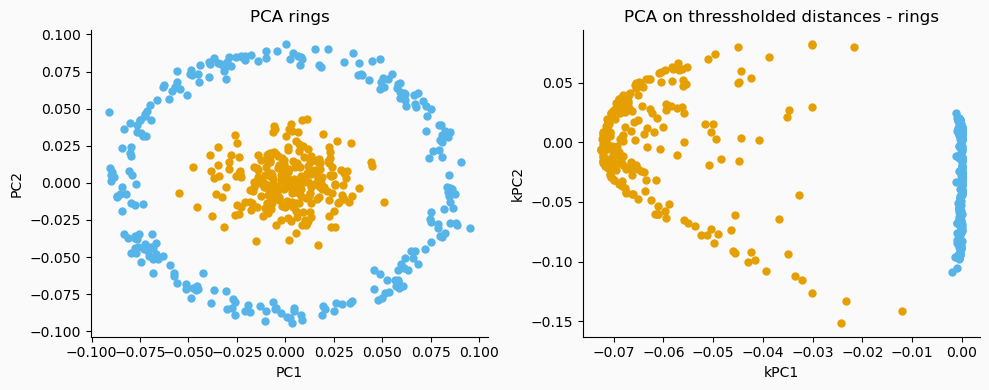

In [17]:

U_pca1, s_pca1, Vt_pca1 = svd(X_rings, full_matrices=False)  # PCA
pca1 = (U_pca1, s_pca1, Vt_pca1)
dd = pd.DataFrame(np.c_[U_pca1[:, :2], data_plot2["cluster"]], columns=["PC1", "PC2", "cluster"])
dd[["PC1", "PC2"]] = dd[["PC1", "PC2"]].astype(float)

fig_, axes = plt.subplots(1, 2, figsize=(10, 4))
scatter_panel(axes[0], dd, "PC1", "PC2", "cluster", title="PCA rings")

# PCA on threshholded distances
dd2 = pd.DataFrame({"kPC1": U[:, 0], "kPC2": U[:, 1], "cluster": data_plot2["cluster"].values})
scatter_panel(axes[1], dd2, "kPC1", "kPC2", "cluster", title="PCA on thressholded distances - rings")
plt.tight_layout()
plt.show()


The idea of using kernel methods to produce flexible distance matrices and analyzin the thresholded distances is formally used in so-called spectral clustering; where we now perform kmeans in the PC space of the adjacency matrices. In upcoming lectures we will discuss this in more detail, how many components that are needed and how to properly normalize the adjacency matrices before etc.

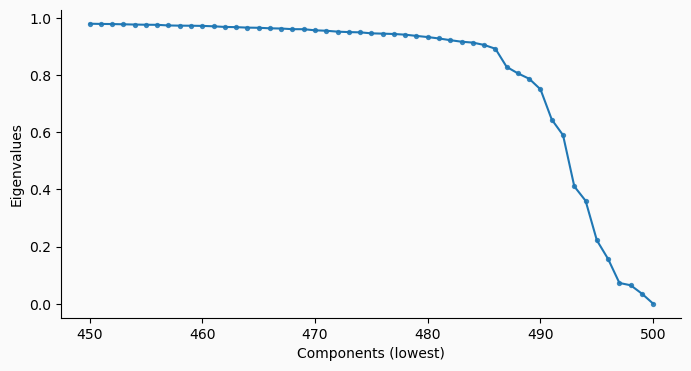

[4.58827942e-17 3.50687769e-02 6.45911099e-02 7.26495488e-02
 1.56373959e-01 2.21976874e-01 3.60305211e-01 4.10613598e-01
 5.89888694e-01 6.44451080e-01]


In [18]:

deuc_adj = deuc_th.copy()  # thresholded matrix
np.fill_diagonal(deuc_adj, 0)  # remove self-similarity
deg = deuc_adj.sum(axis=1)
deg_safe = np.where(deg > 0, deg, 1)
lapl = np.diag(1 / np.sqrt(deg_safe)) @ (np.diag(deg) - deuc_adj) @ np.diag(1 / np.sqrt(deg_safe))  # normalized Laplacian
U_l, ssl_d, Vt_l = svd(lapl, full_matrices=False)
ssl = (U_l, ssl_d, Vt_l)
eiglp = pd.DataFrame({"eigen": ssl_d, "pc": np.arange(1, len(ssl_d) + 1)})

plt.figure(figsize=(8, 4))
plt.scatter(eiglp.iloc[-51:]["pc"], eiglp.iloc[-51:]["eigen"], s=8, alpha=0.8)
plt.plot(eiglp.iloc[-51:]["pc"], eiglp.iloc[-51:]["eigen"])
plt.xlabel("Components (lowest)")
plt.ylabel("Eigenvalues")
plt.show()

print(ssl_d[::-1][:10])


The last component is essentially 0. As we shall see in the lecture, this is because the threshholded graph still connects all data points to one another (one connected component). But what about the other leading small components?


['Index', 'PC500', 'PC499', 'PC498', 'cluster']


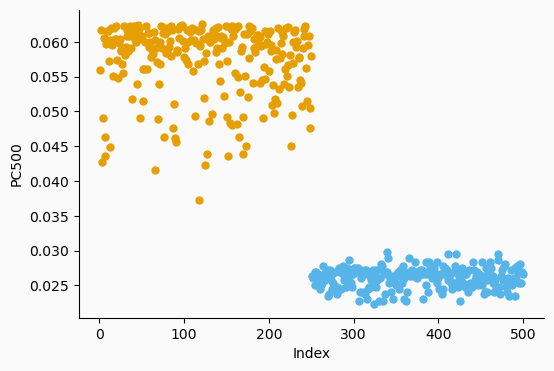

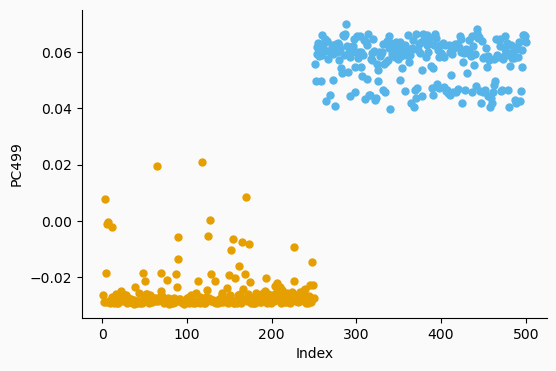

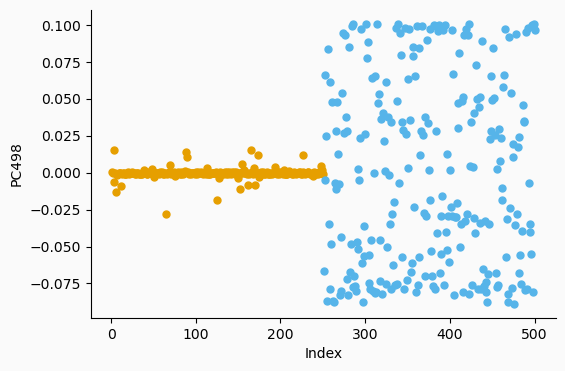

In [19]:

pclp = pd.DataFrame({
    "Index": np.arange(1, U_l.shape[0] + 1),
    f"PC{U_l.shape[1]}": U_l[:, -1],
    f"PC{U_l.shape[1]-1}": U_l[:, -2],
    f"PC{U_l.shape[1]-2}": U_l[:, -3],
    "cluster": data_plot2["cluster"].values
})

print(pclp.columns.tolist())

for col in [f"PC{U_l.shape[1]}", f"PC{U_l.shape[1]-1}", f"PC{U_l.shape[1]-2}"]:
    plt.figure(figsize=(6, 4))
    ax = plt.gca()
    scatter_panel(ax, pclp, "Index", col, "cluster", title="", xlabel="Index", ylabel=col)
    plt.show()


c:\Users\jornsten\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Det går inte att hitta filen
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\jornsten\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\jornsten\AppData\Local\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jornsten\AppData\Local\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\jornsten\AppData\Local\anaconda3\Lib\subprocess.py

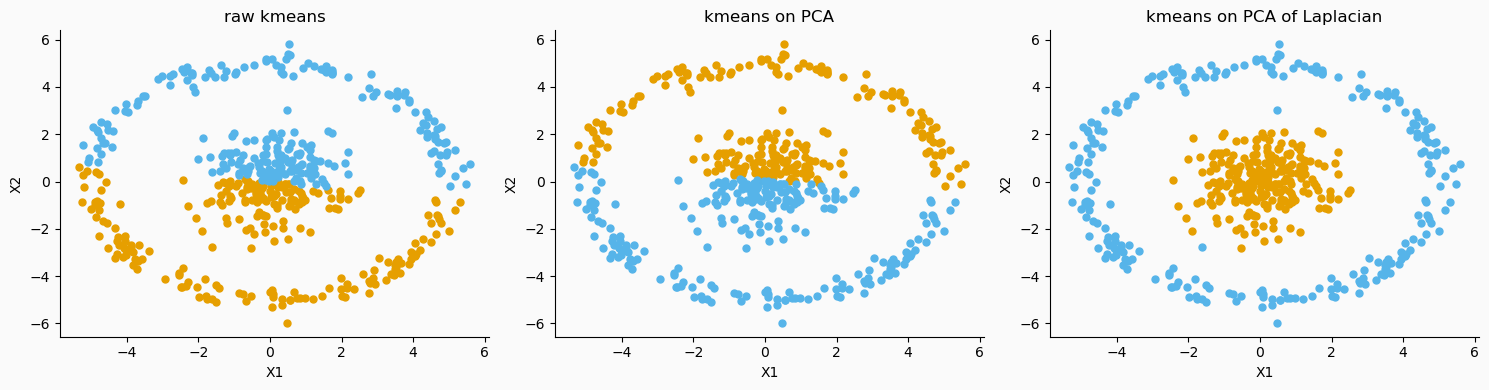

In [20]:

kmeans_raw = KMeans(n_clusters=2, n_init=10, random_state=1).fit(X_rings)  # kmeans on data
kmeans_pca = KMeans(n_clusters=2, n_init=10, random_state=1).fit(U_pca1[:, :2])  # kmeans on PCA
kmeans_spec = KMeans(n_clusters=2, n_init=10, random_state=1).fit(U_l[:, -2:])  # kmeans on PC of Laplacian

dd = pd.DataFrame({"X1": data_plot2["x"], "X2": data_plot2["y"], "cluster": (kmeans_raw.labels_ + 1).astype(str)})
dd2 = pd.DataFrame({"X1": data_plot2["x"], "X2": data_plot2["y"], "cluster": (kmeans_pca.labels_ + 1).astype(str)})
dd3 = pd.DataFrame({"X1": data_plot2["x"], "X2": data_plot2["y"], "cluster": (kmeans_spec.labels_ + 1).astype(str)})

fig_, axes = plt.subplots(1, 3, figsize=(15, 4))
scatter_panel(axes[0], dd, "X1", "X2", "cluster", title="raw kmeans")
scatter_panel(axes[1], dd2, "X1", "X2", "cluster", title="kmeans on PCA")
scatter_panel(axes[2], dd3, "X1", "X2", "cluster", title="kmeans on PCA of Laplacian")
plt.tight_layout()
plt.show()
